# Ciclo invertido: parámetros → DDPM → imagen → Xception → parámetros

Pipeline:
1. **DDPM condicionado**: vector de 8 parámetros → imagen `(40×40)` en `[-1,1]`
2. **Xception inverso**: imagen croppeada `(39×39)` → re-estima los 8 parámetros
3. **Métricas**: R² y MAE globales + galería de generación

**Dataset**: `dataset-united.npz` — `img (N,39,39,1)` con `⟨sz⟩` promedio de 5 capas.

**Padding/crop**:
- `dataset → DDPM`: pad con 0 de `(39,39)` → `(40,40)`
- `DDPM → métricas / Xception`: crop `[:39,:39]`

## 0 · Setup y descarga desde Kaggle

In [ ]:
import subprocess, sys

def pip(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

pip("kaggle")
pip("scikit-image")

import os
from google.colab import files

if not os.path.exists("/root/.kaggle/kaggle.json"):
    print("Sube tu kaggle.json:")
    uploaded = files.upload()
    os.makedirs("/root/.kaggle", exist_ok=True)
    with open("/root/.kaggle/kaggle.json", "wb") as fp:
        fp.write(list(uploaded.values())[0])
    os.chmod("/root/.kaggle/kaggle.json", 0o600)
else:
    print("kaggle.json ya existe.")

WORKDIR  = "/content"
DATA_DIR = f"{WORKDIR}/kaggle_data"
os.makedirs(DATA_DIR, exist_ok=True)

datasets = [
    "carloscanamejoy/dataset-spines-united-v2",  # ← dataset ORIGINAL (para ajustar scalers)
    "carloscanamejoy/dataset-new-hez",           # ← dataset EXTERNO (para evaluar)
    "carloscanamejoy/weights-xception-model",
    "carloscanamejoy/weights-models",
]
for ds in datasets:
    name = ds.split("/")[1]
    dest = f"{DATA_DIR}/{name}"
    if not os.path.exists(dest):
        print(f"Descargando {ds} ...")
        subprocess.check_call(["kaggle","datasets","download","-d",ds,"-p",dest,"--unzip"])
    else:
        print(f"  Ya existe: {dest}")

Sube tu kaggle.json:


Saving kaggle.json to kaggle.json
Descargando carloscanamejoy/dataset-spines-united-v2 ...
Descargando carloscanamejoy/dataset-new-hez ...
Descargando carloscanamejoy/weights-xception-model ...
Descargando carloscanamejoy/weights-models ...


## 1 · Rutas y constantes

In [ ]:
from pathlib import Path
import os
import numpy as np

WORKDIR  = "/content"
DATA_DIR = f"{WORKDIR}/kaggle_data"

# ── DATASETS ─────────────────────────────────────────────────────────────────
# ORIGINAL: con el que se entrenaron DDPM y Xception. Se usa SOLO para
#           reconstruir los scalers (data_min_/data_max_) y mn/mx de imagen.
# EXTERNO : tu dataset nuevo simulado. Se usa SOLO para evaluar el ciclo.
DATASET_ORIG_PATH = Path(f"{DATA_DIR}/dataset-spines-united-v2/dataset_unificado_v2.npz")
DATASET_EVAL_PATH = Path(f"{DATA_DIR}/dataset-new-hez/dataset-hez-profdario.npz")

XCEPTION_INV_WEIGHTS = Path(f"{DATA_DIR}/weights-xception-model/modelo_xception_fulldatabaseV3100.h5")
DDPM_CHECKPOINT      = Path(f"{DATA_DIR}/weights-models/ddpm_spines_final_39crop.pt")
# ─────────────────────────────────────────────────────────────────────────────

for p in [DATASET_ORIG_PATH, DATASET_EVAL_PATH, XCEPTION_INV_WEIGHTS, DDPM_CHECKPOINT]:
    print(f"[{'OK' if p.exists() else 'NO ENCONTRADO'}] {p}")

PARAM_NAMES = ["T", "Jex2", "Jex3", "Jex4", "Kan1", "KanS", "Hex", "KDM"]
N_OUTPUTS   = 8
COND_DIM    = 8

# Grilla y geometría
GRID          = 39
DDPM_IMG_SIZE = 40
RD_PIXELS     = 18.3

cx = cy = GRID // 2
_y, _x = np.ogrid[:GRID, :GRID]
DISK_MASK_39 = np.sqrt((_x-cx)**2 + (_y-cy)**2) <= RD_PIXELS

# Splits (DETERMINISTAS, idénticos al entrenamiento — SEED=42)
INV_SPLIT_SEED       = 42
INV_TEST_FRACTION    = 0.15
INV_VAL_FRACTION_REL = 0.1765
DDPM_SEED            = 42
DDPM_SUBSAMPLE_FRAC  = 1.0

# Inferencia
TARGET_HW_INV   = (224, 224)
DDPM_FAST_STEPS = 100
N_BATCH_EVAL    = 1000     # nº de muestras del dataset externo a evaluar (None = todas)
BATCH_SEED      = 7
EPS_REL_FRAC    = 0.01
ACC_THRESHOLD   = 10.0

print("\nConfigurado.")
print(f"  Scalers se ajustan sobre : DATASET ORIGINAL (70% train)")
print(f"  Evaluación se hace sobre  : DATASET EXTERNO")
print(f"  Grilla {GRID}×{GRID}  →  pad reflect  →  {DDPM_IMG_SIZE}×{DDPM_IMG_SIZE}")

[OK] /content/kaggle_data/dataset-spines-united-v2/dataset_unificado_v2.npz
[OK] /content/kaggle_data/dataset-new-hez/dataset-hez-profdario.npz
[OK] /content/kaggle_data/weights-xception-model/modelo_xception_fulldatabaseV3100.h5
[OK] /content/kaggle_data/weights-models/ddpm_spines_final_39crop.pt

Configurado.
  Scalers se ajustan sobre : DATASET ORIGINAL (70% train)
  Evaluación se hace sobre  : DATASET EXTERNO
  Grilla 39×39  →  pad reflect  →  40×40


## 2 · Imports y dataset

In [ ]:
import os, math, time, sys, subprocess, gc
os.environ.setdefault("KERAS_BACKEND", "tensorflow")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

try:
    from skimage.metrics import structural_similarity as ssim_fn
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-image"])
    from skimage.metrics import structural_similarity as ssim_fn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"TF: {tf.__version__} | Torch: {torch.__version__} | Device: {DEVICE}")
for gpu in tf.config.list_physical_devices("GPU"):
    try: tf.config.experimental.set_memory_growth(gpu, True)
    except: pass

# ── Dataset ORIGINAL (para ajustar scalers) ──────────────────────────────────
data_orig   = np.load(DATASET_ORIG_PATH, mmap_mode="r")
imgs_orig_ds = data_orig["img"]
params_orig  = np.asarray(data_orig["params"])
N_orig = imgs_orig_ds.shape[0]
print(f"\nDataset ORIGINAL: {N_orig:,} muestras")
print(f"  imgs   : {imgs_orig_ds.shape}  {imgs_orig_ds.dtype}")
print(f"  params : {params_orig.shape}")

# ── Dataset EXTERNO (para evaluar) ────────────────────────────────────────────
data_eval   = np.load(DATASET_EVAL_PATH, mmap_mode="r")
imgs        = data_eval["img"]               # (N,39,39,1)  ← se evalúa este
params      = np.asarray(data_eval["params"])
N = imgs.shape[0]
print(f"\nDataset EXTERNO (eval): {N:,} muestras")
print(f"  imgs   : {imgs.shape}  {imgs.dtype}")
print(f"  params : {params.shape}")

# ── Comparar rangos de parámetros (diagnóstico del problema) ──────────────────
print("\n── Comparación de rangos por parámetro (orig vs externo) ──")
print(f"  {'param':<6}  {'orig [min, max]':<24}  {'externo [min, max]':<24}")
for j, name in enumerate(PARAM_NAMES):
    o_lo, o_hi = params_orig[:,j].min(), params_orig[:,j].max()
    e_lo, e_hi = params[:,j].min(), params[:,j].max()
    flag = "  <-- DIFIERE" if (abs(o_lo-e_lo) > 1e-6 or abs(o_hi-e_hi) > 1e-6) else ""
    print(f"  {name:<6}  [{o_lo:8.4f}, {o_hi:8.4f}]    [{e_lo:8.4f}, {e_hi:8.4f}]{flag}")

TF: 2.20.0 | Torch: 2.11.0+cu128 | Device: cuda

Dataset ORIGINAL: 169,671 muestras
  imgs   : (169671, 39, 39, 1)  float32
  params : (169671, 8)

Dataset EXTERNO (eval): 12,163 muestras
  imgs   : (12163, 39, 39, 1)  float32
  params : (12163, 8)

── Comparación de rangos por parámetro (orig vs externo) ──
  param   orig [min, max]           externo [min, max]      
  T       [  0.0000,  20.0000]    [  0.2000,  20.0000]  <-- DIFIERE
  Jex2    [ -0.2860,   0.6590]    [  0.0000,   0.0000]  <-- DIFIERE
  Jex3    [ -0.2900,   0.2900]    [  0.0000,   0.0000]  <-- DIFIERE
  Jex4    [ -0.2340,   0.2350]    [  0.0000,   0.0000]  <-- DIFIERE
  Kan1    [  0.0000,   0.5997]    [  0.0010,   0.1990]  <-- DIFIERE
  KanS    [  0.0000,   0.2000]    [  0.0000,   0.2000]
  Hex     [  0.0000,   1.1988]    [  0.0010,   1.4940]  <-- DIFIERE
  KDM     [  0.0000,   1.2000]    [  0.0000,   1.1970]  <-- DIFIERE


## 3 · Splits y scalers

In [ ]:
# =============================================================================
# Los scalers y mn/mx se ajustan SOLO sobre el dataset ORIGINAL, replicando
# EXACTAMENTE los splits deterministas del entrenamiento (SEED=42).
# NUNCA se re-ajustan sobre el dataset externo: eso era el bug que desalineaba
# el mapeo físico→normalizado que aprendió el DDPM/Xception.
# =============================================================================

# ── scaler_inv (Xception) — split 70/15/15 sobre dataset ORIGINAL ────────────
all_idx_o = np.arange(N_orig)
idx_train_pool, idx_test_inv, _, _ = train_test_split(
    all_idx_o, params_orig, test_size=INV_TEST_FRACTION, random_state=INV_SPLIT_SEED)
idx_train_inv, idx_val_inv, _, _ = train_test_split(
    idx_train_pool, params_orig[idx_train_pool],
    test_size=INV_VAL_FRACTION_REL, random_state=INV_SPLIT_SEED)
scaler_inv = MinMaxScaler().fit(params_orig[idx_train_inv])
print("scaler_inv (sobre ORIGINAL):")
print(f"  data_min: {np.round(scaler_inv.data_min_, 4)}")
print(f"  data_max: {np.round(scaler_inv.data_max_, 4)}")

# ── scaler_ddpm + mn/mx — split del DDPM sobre dataset ORIGINAL ──────────────
rng = np.random.RandomState(DDPM_SEED)
sub_idx = rng.choice(N_orig, size=int(N_orig * DDPM_SUBSAMPLE_FRAC), replace=False)
params_sub_raw = params_orig[sub_idx]
imgs_sub       = np.asarray(imgs_orig_ds[sub_idx]).astype(np.float32)

idx_all_sub = np.arange(len(sub_idx))
idx_tr_sub, idx_temp_sub = train_test_split(idx_all_sub, test_size=0.30, random_state=DDPM_SEED)
idx_val_sub, idx_te_sub  = train_test_split(idx_temp_sub, test_size=0.50, random_state=DDPM_SEED)

scaler_ddpm = MinMaxScaler().fit(params_sub_raw[idx_tr_sub])
print("\nscaler_ddpm (sobre ORIGINAL):")
print(f"  data_min: {np.round(scaler_ddpm.data_min_, 4)}")
print(f"  data_max: {np.round(scaler_ddpm.data_max_, 4)}")

# ── mn/mx de imagen — IGUAL que SpinesDataset: pad reflect PRIMERO, luego min/max
#    El entrenamiento calcula mn,mx sobre el tensor YA paddeado a 40x40.
imgs_train_39 = imgs_sub[idx_tr_sub].astype(np.float32)   # (Ntr,39,39,1)
if imgs_train_39.ndim == 4:
    imgs_train_39 = imgs_train_39[..., 0]                 # (Ntr,39,39)
# Pad reflect 39->40 en cada imagen
imgs_train_40 = np.pad(imgs_train_39, ((0,0),(0,1),(0,1)), mode='reflect')  # (Ntr,40,40)
mn, mx = float(imgs_train_40.min()), float(imgs_train_40.max())
print(f"\nNorm imagen DDPM (sobre paddeado 40x40): mn={mn:.4f}  mx={mx:.4f}")

# ── Verificación contra el entrenamiento ──────────────────────────────────────
print("\nValores esperados del entrenamiento (compáralos con los de arriba):")
print("  Si scaler_ddpm.data_min_/max_ y mn/mx coinciden con los impresos")
print("  durante el retrain, los scalers están correctos.")

scaler_inv (sobre ORIGINAL):
  data_min: [ 0.    -0.286 -0.29  -0.234  0.     0.     0.     0.   ]
  data_max: [20.      0.659   0.29    0.235   0.5997  0.2     1.1988  1.2   ]

scaler_ddpm (sobre ORIGINAL):
  data_min: [ 0.    -0.286 -0.29  -0.234  0.     0.     0.     0.   ]
  data_max: [20.      0.659   0.29    0.235   0.5997  0.2     1.1988  1.2   ]

Norm imagen DDPM (sobre paddeado 40x40): mn=-1.0000  mx=1.0000

Valores esperados del entrenamiento (compáralos con los de arriba):
  Si scaler_ddpm.data_min_/max_ y mn/mx coinciden con los impresos
  durante el retrain, los scalers están correctos.


## 4 · GPU config y Xception

In [ ]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth activado.")
    except RuntimeError as e:
        print(f"GPU config error: {e}")

from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import (Input, GlobalAveragePooling2D, Dense,
                                     BatchNormalization, Dropout)
from tensorflow.keras.models import Model

def build_xception(n_outputs=8):
    inputs = Input(shape=(224, 224, 3), name="input_layer")
    base   = Xception(weights=None, include_top=False, input_tensor=inputs)
    x = GlobalAveragePooling2D(name="global_average_pooling2d")(base.output)
    x = BatchNormalization(name="batch_normalization_4")(x)
    x = Dropout(0.4, name="dropout")(x)
    x = Dense(256, activation="relu", name="dense")(x)
    x = BatchNormalization(name="batch_normalization_5")(x)
    x = Dropout(0.3, name="dropout_1")(x)
    out = Dense(n_outputs, activation="linear", name="dense_1")(x)
    return Model(inputs, out, name="xception_inverso_V3100")

with tf.device('/cpu:0'):
    xception_model = build_xception()
    xception_model.load_weights(XCEPTION_INV_WEIGHTS)
print(f"Xception cargado en CPU. params={xception_model.count_params():,}")

Memory growth activado.
Xception cargado en CPU. params=21,397,296


## 5 · DDPM

In [ ]:
T_STEPS    = 1000
BETA_START = 1e-4
BETA_END   = 0.02

class DDPMScheduler:
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02, schedule="linear", device="cpu"):
        self.T = T
        if schedule == "linear":
            betas = torch.linspace(beta_start, beta_end, T, device=device)
        elif schedule == "cosine":
            steps = T + 1; s = 0.008
            x  = torch.linspace(0, T, steps, device=device)
            ac = torch.cos(((x/T)+s)/(1+s)*math.pi*0.5)**2
            ac = ac/ac[0]
            betas = (1-ac[1:]/ac[:-1]).clamp(max=0.999)
        else: raise ValueError(schedule)
        alphas = 1.0 - betas
        ac = torch.cumprod(alphas, dim=0)
        self.betas=betas; self.alphas=alphas; self.alphas_cumprod=ac
        self.sqrt_alphas_cumprod           = ac.sqrt()
        self.sqrt_one_minus_alphas_cumprod = (1.0-ac).sqrt()
        ac_prev = F.pad(ac[:-1],(1,0),value=1.0)
        self.posterior_variance = betas*(1-ac_prev)/(1-ac)
        self.sqrt_recip_alphas  = (1.0/alphas).sqrt()

def sinusoidal_embedding(t, dim):
    half  = dim//2
    freqs = torch.exp(-math.log(10000)*torch.arange(half,device=t.device).float()/(half-1))
    args  = t[:,None].float()*freqs[None]
    return torch.cat([args.sin(),args.cos()],dim=-1)

class TimeCondEmbedding(nn.Module):
    def __init__(self,t_dim,cond_in,out_dim):
        super().__init__()
        self.t_mlp=nn.Sequential(nn.Linear(t_dim,out_dim),nn.SiLU(),nn.Linear(out_dim,out_dim))
        self.c_mlp=nn.Sequential(nn.Linear(cond_in,out_dim),nn.SiLU(),nn.Linear(out_dim,out_dim))
    def forward(self,t,cond):
        return self.t_mlp(sinusoidal_embedding(t,self.t_mlp[0].in_features))+self.c_mlp(cond)

class ResBlock(nn.Module):
    def __init__(self,in_ch,out_ch,emb_dim,groups=8,dropout=0.0):
        super().__init__()
        self.norm1=nn.GroupNorm(groups,in_ch);  self.conv1=nn.Conv2d(in_ch,out_ch,3,padding=1)
        self.norm2=nn.GroupNorm(groups,out_ch); self.conv2=nn.Conv2d(out_ch,out_ch,3,padding=1)
        self.emb_proj=nn.Linear(emb_dim,out_ch)
        self.dropout=nn.Dropout(dropout) if dropout>0 else nn.Identity()
        self.skip=nn.Conv2d(in_ch,out_ch,1) if in_ch!=out_ch else nn.Identity()
    def forward(self,x,emb):
        h=F.silu(self.norm1(x));h=self.conv1(h)
        h=h+self.emb_proj(F.silu(emb))[:,:,None,None]
        h=F.silu(self.norm2(h));h=self.dropout(h);h=self.conv2(h)
        return h+self.skip(x)

class SelfAttention(nn.Module):
    def __init__(self,ch,groups=8):
        super().__init__()
        self.norm=nn.GroupNorm(groups,ch)
        self.qkv=nn.Conv2d(ch,ch*3,1); self.proj=nn.Conv2d(ch,ch,1)
    def forward(self,x):
        B,C,H,W=x.shape; h=self.norm(x)
        q,k,v=self.qkv(h).chunk(3,dim=1)
        q=q.reshape(B,C,-1);k=k.reshape(B,C,-1);v=v.reshape(B,C,-1)
        attn=torch.softmax(torch.bmm(q.transpose(1,2),k)/math.sqrt(C),dim=-1)
        return x+self.proj(torch.bmm(v,attn.transpose(1,2)).reshape(B,C,H,W))

class ConditionalUNet(nn.Module):
    def __init__(self,img_channels=1,base_ch=64,ch_mults=(1,2,4),
                 cond_dim=8,emb_dim=128,dropout=0.0):
        super().__init__()
        chs=[base_ch*m for m in ch_mults]
        self.emb=TimeCondEmbedding(t_dim=emb_dim,cond_in=cond_dim,out_dim=emb_dim)
        self.conv_in=nn.Conv2d(img_channels,chs[0],3,padding=1)
        self.down_blocks=nn.ModuleList();self.down_samples=nn.ModuleList();self.skip_channels=[]
        in_ch=chs[0]
        for i,out_ch in enumerate(chs):
            self.down_blocks.append(nn.ModuleList([
                ResBlock(in_ch,out_ch,emb_dim,dropout=dropout),
                ResBlock(out_ch,out_ch,emb_dim,dropout=dropout),
            ]))
            self.skip_channels.append(out_ch)
            self.down_samples.append(nn.Conv2d(out_ch,out_ch,4,stride=2,padding=1) if i<len(chs)-1 else nn.Identity())
            in_ch=out_ch
        self.mid_block1=ResBlock(chs[-1],chs[-1],emb_dim,dropout=dropout)
        self.mid_attn=SelfAttention(chs[-1])
        self.mid_block2=ResBlock(chs[-1],chs[-1],emb_dim,dropout=dropout)
        self.up_blocks=nn.ModuleList();self.up_samples=nn.ModuleList()
        for i,out_ch in enumerate(reversed(chs)):
            skip_ch=self.skip_channels[-(i+1)]
            self.up_blocks.append(nn.ModuleList([
                ResBlock(in_ch+skip_ch,out_ch,emb_dim,dropout=dropout),
                ResBlock(out_ch,out_ch,emb_dim,dropout=dropout),
            ]))
            self.up_samples.append(nn.ConvTranspose2d(out_ch,out_ch,4,stride=2,padding=1) if i<len(chs)-1 else nn.Identity())
            in_ch=out_ch
        self.norm_out=nn.GroupNorm(8,chs[0])
        self.conv_out=nn.Conv2d(chs[0],img_channels,1)
    def forward(self,x,t,cond):
        emb=self.emb(t,cond);h=self.conv_in(x);skips=[]
        for (rb1,rb2),ds in zip(self.down_blocks,self.down_samples):
            h=rb1(h,emb);h=rb2(h,emb);skips.append(h);h=ds(h)
        h=self.mid_block1(h,emb);h=self.mid_attn(h);h=self.mid_block2(h,emb)
        for (rb1,rb2),us,sk in zip(self.up_blocks,self.up_samples,reversed(skips)):
            h=torch.cat([h,sk],dim=1);h=rb1(h,emb);h=rb2(h,emb);h=us(h)
        return self.conv_out(F.silu(self.norm_out(h)))

@torch.no_grad()
def fast_sample(model,cond,scheduler,n_steps=100,img_size=DDPM_IMG_SIZE):
    model.eval()
    B=cond.shape[0]
    x=torch.randn(B,1,img_size,img_size,device=cond.device)
    timesteps=list(range(0,scheduler.T,scheduler.T//n_steps))[::-1]
    for t_val in timesteps:
        t_tensor=torch.full((B,),t_val,device=cond.device,dtype=torch.long)
        eps_pred=model(x,t_tensor,cond)
        sqrt_a=scheduler.sqrt_alphas_cumprod[t_val]
        sqrt_1a=scheduler.sqrt_one_minus_alphas_cumprod[t_val]
        x0_pred=((x-sqrt_1a*eps_pred)/sqrt_a).clamp(-1,1)
        if t_val>0:
            t_prev=max(t_val-scheduler.T//n_steps,0)
            x=scheduler.sqrt_alphas_cumprod[t_prev]*x0_pred+scheduler.sqrt_one_minus_alphas_cumprod[t_prev]*eps_pred
        else:
            x=x0_pred
    return x

print("Cargando DDPM checkpoint...")
ckpt=torch.load(DDPM_CHECKPOINT,map_location=DEVICE,weights_only=False)
hp=ckpt["hyperparams"]
print(f"  Hiperparams: {hp}")

ddpm_model=ConditionalUNet(
    img_channels=1,base_ch=hp["base_ch"],ch_mults=(1,2,4),
    cond_dim=COND_DIM,emb_dim=hp["cond_emb_dim"],dropout=0.0,
).to(DEVICE)

if "ema" in ckpt and ckpt["ema"] is not None:
    ddpm_model.load_state_dict(ckpt["ema"]); print("  EMA cargado.")
else:
    ddpm_model.load_state_dict(ckpt["model"]); print("  Modelo (no-EMA) cargado.")
ddpm_model.eval()

ddpm_scheduler=DDPMScheduler(T=T_STEPS,beta_start=BETA_START,beta_end=BETA_END,
                              schedule=hp["beta_schedule"],device=DEVICE)
print(f"  DDPM OK | base_ch={hp['base_ch']} | beta={hp['beta_schedule']}")

Cargando DDPM checkpoint...
  Hiperparams: {'lr': 0.00022640535194211016, 'batch_size': 128, 'base_ch': 80, 'cond_emb_dim': 128, 'dropout': 0.1, 'beta_schedule': 'cosine', 'ema_decay': 0.999, 'weight_decay': 4.279388675327132e-05, 'min_snr_gamma': 5.0}
  EMA cargado.
  DDPM OK | base_ch=80 | beta=cosine


## 6 · Preprocesos e inferencia

**Regla de padding/crop:**
- `dataset_img_to_ddpm`: imagen `(39,39,1)` → **pad cero** → `(40,40)` en `[-1,1]`
- `ddpm_img_to_xception_input`: imagen DDPM `(40,40)` → **crop `[:39,:39]`** → resize `224×224` → Xception
- Métricas de imagen: **crop `[:39,:39]`** en ambos lados antes de calcular MSE/SSIM/FFT

In [ ]:
# ── Preprocesos ───────────────────────────────────────────────────────────────

def dataset_img_to_ddpm(img_39):
    """
    Imagen original (39,39,1) o (39,39) del dataset
    → pad reflect (39→40) → normalizar con mn/mx → [-1,1].
    EXACTAMENTE igual que SpinesDataset en el entrenamiento del DDPM:
    pad PRIMERO, normalizar DESPUÉS.
    """
    x = np.asarray(img_39, dtype=np.float32)
    if x.ndim == 3:
        x = x[..., 0]                                            # (39,39)
    x = np.pad(x, ((0, 1), (0, 1)), mode='reflect')             # (40,40) PRIMERO
    x = (x - mn) / (mx - mn + 1e-8)                             # [0,1]
    x = x * 2.0 - 1.0                                           # [-1,1]
    return x.astype(np.float32)

def crop39(img_40):
    """Crop (40,40) → (39,39). Aplica antes de métricas y Xception."""
    return np.asarray(img_40, dtype=np.float32)[:39, :39]

def ddpm_img_to_xception_input(img_40):
    """
    Imagen DDPM (40,40) en [-1,1]
    → crop [:39,:39]
    → deshacer norm DDPM → espacio físico
    → resize 224×224 → grayscale_to_rgb → tensor (1,224,224,3)
    """
    x = crop39(img_40)                           # (39,39)
    x = (x + 1.0) / 2.0 * (mx - mn) + mn       # espacio físico
    x = x[..., None]                             # (39,39,1)
    x = tf.image.resize(x[None, ...], TARGET_HW_INV)   # (1,224,224,1)
    x = tf.image.grayscale_to_rgb(x)             # (1,224,224,3)
    return x

def params_phys_to_ddpm_cond(y_phys):
    y = np.asarray(y_phys, dtype=np.float32).reshape(1, -1)
    return scaler_ddpm.transform(y).ravel().astype(np.float32)

# ── Generación ────────────────────────────────────────────────────────────────

@torch.no_grad()
def generate_with_ddpm(y_phys, n_steps=DDPM_FAST_STEPS):
    """Genera una imagen (40,40) en [-1,1]."""
    cond   = params_phys_to_ddpm_cond(y_phys)
    cond_t = torch.tensor(cond[None,:], dtype=torch.float32, device=DEVICE)
    x = fast_sample(ddpm_model, cond_t, ddpm_scheduler,
                    n_steps=n_steps, img_size=DDPM_IMG_SIZE)
    return x.cpu().numpy()[0, 0]   # (40,40)

@torch.no_grad()
def generate_with_ddpm_batch(y_phys_batch, n_steps=DDPM_FAST_STEPS):
    """Genera un batch de imágenes (B,40,40) en [-1,1]."""
    cond   = scaler_ddpm.transform(np.asarray(y_phys_batch, dtype=np.float32))
    cond_t = torch.tensor(cond, dtype=torch.float32, device=DEVICE)
    x = fast_sample(ddpm_model, cond_t, ddpm_scheduler,
                    n_steps=n_steps, img_size=DDPM_IMG_SIZE)
    return x.cpu().numpy()[:, 0]   # (B,40,40)

# ── Inferencia Xception ───────────────────────────────────────────────────────

def infer_params_from_ddpm_img(img_40):
    """Un solo estado: crop → Xception → parámetros físicos."""
    x     = ddpm_img_to_xception_input(img_40)
    y_norm = xception_model.predict(x, verbose=0)[0]
    return scaler_inv.inverse_transform(
        np.asarray(y_norm, dtype=np.float32).reshape(1,-1)).ravel()

XCEPTION_INFER_BATCH = 32

def infer_params_from_ddpm_batch(imgs_40_batch, batch_size=XCEPTION_INFER_BATCH):
    """
    Batch (N,40,40): crop [:39,:39] → deshacer norm → resize 224 → Xception.
    Procesado en mini-batches para evitar OOM.
    """
    N    = imgs_40_batch.shape[0]
    results = []
    with tf.device('/cpu:0'):
        for start in range(0, N, batch_size):
            end   = min(start + batch_size, N)
            chunk = imgs_40_batch[start:end].astype(np.float32)
            chunk = chunk[:, :39, :39]                        # crop
            chunk = (chunk + 1.0) / 2.0 * (mx - mn) + mn    # físico
            chunk = chunk[..., None]                          # (B,39,39,1)
            chunk = tf.image.resize(chunk, TARGET_HW_INV)    # (B,224,224,1)
            chunk = tf.image.grayscale_to_rgb(chunk)          # (B,224,224,3)
            y_norm = xception_model.predict(chunk, verbose=0)
            results.append(scaler_inv.inverse_transform(y_norm))
    return np.concatenate(results, axis=0)   # (N,8)

print("Preprocesos configurados.")
print("  dataset → DDPM : pad constante -1.0  →  (40,40)")
print("  DDPM → métricas: crop [:39,:39]  →  (39,39)")
print("  DDPM → Xception: crop [:39,:39]  →  resize 224  →  RGB")

Preprocesos configurados.
  dataset → DDPM : pad constante -1.0  →  (40,40)
  DDPM → métricas: crop [:39,:39]  →  (39,39)
  DDPM → Xception: crop [:39,:39]  →  resize 224  →  RGB


## 7 · Métricas

In [ ]:
# ── Métricas de imagen (operan sobre (39,39) ya croppeadas) ──────────────────

def metric_mse(a, b):
    return float(np.mean((a.astype(np.float64) - b.astype(np.float64))**2))

def metric_ssim(a, b):
    return float(ssim_fn(a, b, data_range=2.0))

def metric_fft(a, b):
    def spec(img):
        f = np.fft.fftshift(np.fft.fft2(img.astype(np.float64)))
        m = np.abs(f); return m / (m.max() + 1e-12)
    Sa, Sb = spec(a), spec(b)
    return dict(mse=float(np.mean((Sa-Sb)**2)),
                corr=float(np.corrcoef(Sa.ravel(), Sb.ravel())[0,1]))

def compute_img_metrics(img_orig_40, img_gen_40):
    """Cropea ambas imágenes a (39,39) y calcula métricas."""
    a = crop39(img_orig_40)
    b = crop39(img_gen_40)
    fft = metric_fft(a, b)
    return dict(mse=metric_mse(a,b), ssim=metric_ssim(a,b),
                fft_mse=fft["mse"], fft_corr=fft["corr"])

# ── Máscara del disco sobre (39,39) ──────────────────────────────────────────

def _disk_mask_39():
    """Máscara booleana (39,39) del disco rd=18.3 px."""
    cy = cx = GRID // 2
    Y, X = np.ogrid[:GRID, :GRID]
    return (X-cx)**2 + (Y-cy)**2 <= RD_PIXELS**2

DISK_MASK = _disk_mask_39()   # (39,39) bool

# ── Métricas físicas (sobre imagen 39×39 croppeada) ───────────────────────────

def spin_magnetization(img39):
    return float(np.mean(img39.astype(np.float64)[DISK_MASK]))

def spin_susceptibility(img39, T, r_cutoff=RD_PIXELS/2):
    if T == 0: return float("nan")
    s    = img39.astype(np.float64)
    N_M  = int(DISK_MASK.sum())
    sbar = (s * DISK_MASK).sum() / N_M
    s_c  = (s - sbar) * DISK_MASK
    G    = np.real(np.fft.ifft2(np.abs(np.fft.fft2(s_c))**2)) / N_M
    H, W = s.shape
    dy = np.arange(H); dy = np.where(dy>H//2, dy-H, dy)
    dx = np.arange(W); dx = np.where(dx>W//2, dx-W, dx)
    DY, DX = np.meshgrid(dy, dx, indexing="ij")
    return float(G[np.sqrt(DY**2+DX**2)<=r_cutoff].sum()/T)

def approx_total_energy(img39):
    s = img39.astype(np.float64) * DISK_MASK
    pd_d = s * np.roll(s,-1,axis=0); md_d = DISK_MASK & np.roll(DISK_MASK,-1,axis=0)
    pd_r = s * np.roll(s,-1,axis=1); md_r = DISK_MASK & np.roll(DISK_MASK,-1,axis=1)
    return float(-(pd_d[md_d].sum()+pd_r[md_r].sum())/int(DISK_MASK.sum()))

def spin_specific_heat(img39, T, block_size=5):
    if T == 0: return float("nan")
    s = img39.astype(np.float64) * DISK_MASK
    H, W = s.shape
    pd_d = s*np.roll(s,-1,axis=0); pd_r = s*np.roll(s,-1,axis=1)
    eps = []
    for r in range(0, H-block_size+1, block_size):
        for c in range(0, W-block_size+1, block_size):
            bm = np.zeros((H,W),bool); bm[r:r+block_size,c:c+block_size]=True
            roi = bm & DISK_MASK
            if roi.sum()!=block_size*block_size: continue
            rd_d=roi&np.roll(roi,-1,axis=0); rd_r=roi&np.roll(roi,-1,axis=1)
            eps.append(-(pd_d[rd_d].sum()+pd_r[rd_r].sum())/(block_size*block_size))
    if len(eps)<2: return float("nan")
    e=np.array(eps); return float(block_size**2*(np.mean(e**2)-np.mean(e)**2)/T**2)

def compute_phys_metrics(img39, T_phys):
    """Métricas físicas sobre imagen (39,39) ya croppeada."""
    return dict(
        M   =spin_magnetization(img39),
        chi =spin_susceptibility(img39, T_phys),
        Cv  =spin_specific_heat(img39, T_phys),
        E   =approx_total_energy(img39),
    )

print("Métricas configuradas.")
print(f"  Disco: {DISK_MASK.sum()} px sobre grilla 39×39")

Métricas configuradas.
  Disco: 1049 px sobre grilla 39×39


## 8 · Estilo visual

In [ ]:
import matplotlib as mpl
from IPython.display import display, HTML

plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white",
    "axes.edgecolor":"#333","axes.labelcolor":"#222",
    "axes.labelsize":11,"axes.titlesize":12,"axes.titleweight":"bold",
    "axes.grid":True,"grid.color":"#ccc","grid.linestyle":"--",
    "grid.alpha":0.5,"grid.linewidth":0.6,
    "xtick.color":"#222","ytick.color":"#222",
    "xtick.labelsize":10,"ytick.labelsize":10,
    "legend.frameon":True,"legend.framealpha":0.92,"legend.fontsize":9,
    "savefig.dpi":140,"savefig.bbox":"tight",
    "font.family":"DejaVu Sans",
})

PARAM_COLORS=["#1f77b4","#ff7f0e","#2ca02c","#d62728",
              "#9467bd","#8c564b","#e377c2","#17becf"]
COLOR_ORIG="#2c5f8d"; COLOR_GEN="#d77a3b"

_TABLE_CSS="""
<style>
.t{border-collapse:collapse;margin:8px 0 14px 0;font-family:sans-serif;font-size:12px;box-shadow:0 1px 3px rgba(0,0,0,.08)}
.t th{background:#2c5f8d;color:#fff;text-align:left;padding:7px 12px;border:1px solid #1d4666;font-weight:600}
.t td{padding:6px 12px;border:1px solid #dde2e6;background:#fff}
.t tr:nth-child(even) td{background:#f5f7fa}
.t tr:hover td{background:#fffbe6}
.t td.num{font-variant-numeric:tabular-nums;text-align:right}
.t td.good{color:#1b6f1b;font-weight:600}.t td.warn{color:#b45f06;font-weight:600}.t td.bad{color:#a30000;font-weight:600}
.tcap{font-weight:600;color:#2c5f8d;margin:10px 0 0 0;font-size:12.5px}
</style>"""

def _fmt(v, nd=4):
    if v is None: return "—"
    if isinstance(v,float) and (np.isnan(v) or np.isinf(v)): return "—"
    if isinstance(v,(int,np.integer)): return f"{int(v):d}"
    return f"{v:.{nd}f}"

def display_df(df, title=None, num_cols=None, color_col=None, thresholds=(5,20), nd=4):
    cols=list(df.columns)
    if num_cols is None:
        num_cols=[c for c in cols if pd.api.types.is_numeric_dtype(df[c])]
    html=[_TABLE_CSS]
    if title: html.append(f'<p class="tcap">{title}</p>')
    html.append('<table class="t"><thead><tr>')
    for c in cols: html.append(f"<th>{c}</th>")
    html.append("</tr></thead><tbody>")
    for _,row in df.iterrows():
        html.append("<tr>")
        for c in cols:
            v=row[c]; cls="num" if c in num_cols else ""
            if color_col and c==color_col:
                try:
                    av=abs(float(v))
                    cls+=(" good" if av<thresholds[0] else " warn" if av<thresholds[1] else " bad")
                except: pass
            html.append(f'<td class="{cls}">{_fmt(v,nd) if c in num_cols else str(v)}</td>')
        html.append("</tr>")
    html.append("</tbody></table>")
    display(HTML("".join(html)))

print("Estilo configurado.")

Estilo configurado.


## 9 · Evaluación masiva

In [ ]:
# ── Selección de muestras del DATASET EXTERNO ────────────────────────────────
# Evaluamos sobre el dataset externo completo (todas sus N muestras), o un
# subsample aleatorio si N_BATCH_EVAL lo limita. NO usamos idx_test_inv aquí
# porque ese split pertenece al dataset original; el externo se evalúa entero.
rng_eval = np.random.RandomState(BATCH_SEED)
if N_BATCH_EVAL is None or N_BATCH_EVAL >= N:
    eval_idx = np.arange(N)
    print(f"Evaluando TODO el dataset externo: {N} muestras.")
else:
    eval_idx = np.sort(rng_eval.choice(N, size=N_BATCH_EVAL, replace=False))
    print(f"Evaluando subsample del dataset externo: {len(eval_idx)} muestras.")
N_pts = len(eval_idx)
y_in  = params[eval_idx].astype(np.float32)

# ── Generar imágenes en batches ───────────────────────────────────────────────
PTS_PER_BATCH = 64
imgs_orig_40  = np.empty((N_pts, DDPM_IMG_SIZE, DDPM_IMG_SIZE), dtype=np.float32)
imgs_gen_40   = np.empty((N_pts, DDPM_IMG_SIZE, DDPM_IMG_SIZE), dtype=np.float32)

print("Generando imágenes DDPM...")
t0 = time.time()
for start in range(0, N_pts, PTS_PER_BATCH):
    end = min(start + PTS_PER_BATCH, N_pts)
    # Originales → pad
    for k in range(start, end):
        imgs_orig_40[k] = dataset_img_to_ddpm(np.asarray(imgs[eval_idx[k]]))
    # Generadas
    imgs_gen_40[start:end] = generate_with_ddpm_batch(y_in[start:end])
    if (end // PTS_PER_BATCH) % 5 == 0 or end == N_pts:
        elapsed = time.time()-t0
        print(f"  {end}/{N_pts}  {elapsed/60:.1f}min")
    gc.collect()

print(f"Generación completada en {(time.time()-t0)/60:.1f} min")

# ── Xception sobre imágenes generadas (crop interno) ─────────────────────────
print("Aplicando Xception (crop [:39,:39] interno)...")
t0 = time.time()
y_pred = infer_params_from_ddpm_batch(imgs_gen_40)
print(f"Xception OK en {time.time()-t0:.1f}s | y_pred shape={y_pred.shape}")

# ── Métricas de imagen (crop [:39,:39] interno) ───────────────────────────────
print("Calculando métricas de imagen...")
img_rows = [compute_img_metrics(imgs_orig_40[k], imgs_gen_40[k]) for k in range(N_pts)]
df_img   = pd.DataFrame(img_rows)
print("Métricas OK.")

Evaluando subsample del dataset externo: 1000 muestras.
Generando imágenes DDPM...
  320/1000  0.1min
  640/1000  0.3min
  960/1000  0.4min
  1000/1000  0.4min
Generación completada en 0.4 min
Aplicando Xception (crop [:39,:39] interno)...
Xception OK en 194.9s | y_pred shape=(1000, 8)
Calculando métricas de imagen...
Métricas OK.


## 10 · R² y MAE globales por parámetro

param,MAE,RMSE,R²,range,nMAE_%
T,0.8669,1.2964,0.8750,19.8000,4.3783
Jex2,0.0685,0.1224,0.0000,0.0000,—
Jex3,0.0263,0.0465,0.0000,0.0000,—
Jex4,0.0204,0.0352,0.0000,0.0000,—
Kan1,0.0780,0.0974,-1.7384,0.1980,39.3840
KanS,0.0878,0.1043,-2.2518,0.2000,43.8910
Hex,0.5422,0.6784,-1.4886,1.4930,36.3187
KDM,0.2210,0.3149,0.1966,1.1970,18.4657


Métrica,Valor
MAE global,0.2389
R² global (var-weighted),0.8357
nMAE % promedio,28.4875


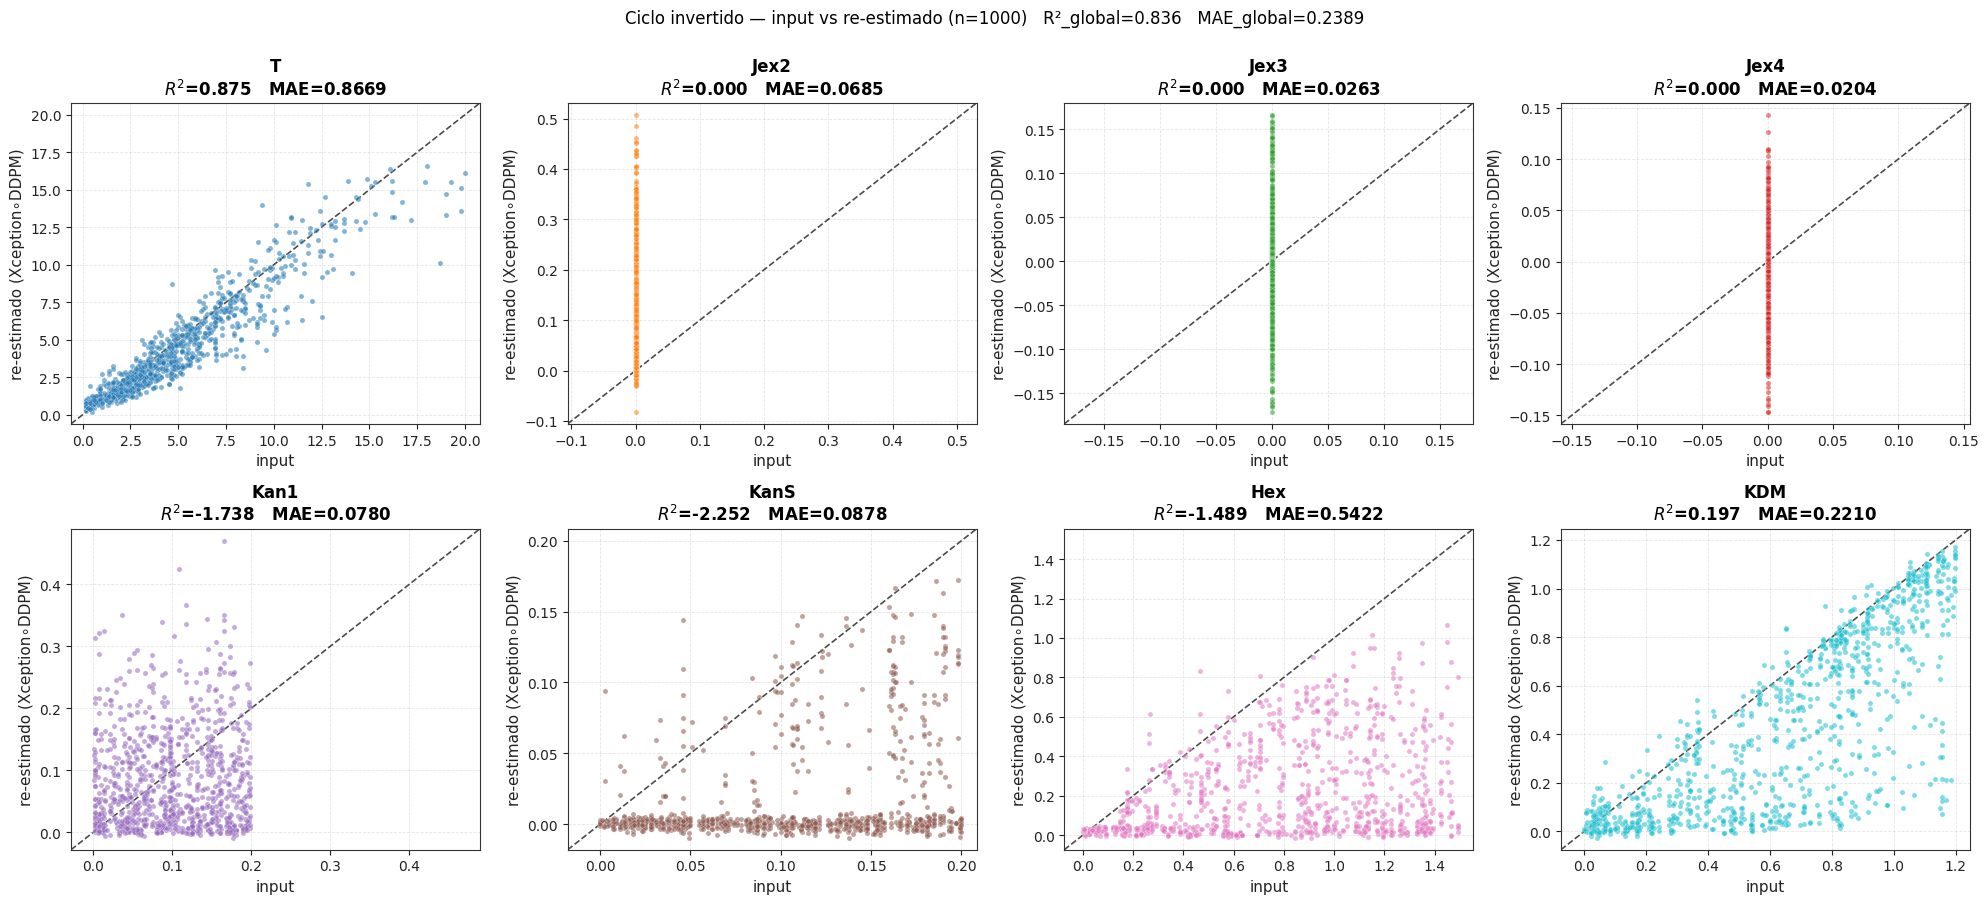

In [ ]:
rows = []
for i, name in enumerate(PARAM_NAMES):
    yt = y_in[:,i]; yp = y_pred[:,i]
    rng_p = yt.max()-yt.min()
    mae   = mean_absolute_error(yt, yp)
    rmse  = mean_squared_error(yt, yp)**0.5
    r2    = r2_score(yt, yp)
    rows.append({"param":name,"MAE":mae,"RMSE":rmse,"R²":r2,
                 "range":rng_p,"nMAE_%":100*mae/rng_p if rng_p>0 else np.nan})
df_reg = pd.DataFrame(rows)

r2_global  = r2_score(y_in, y_pred, multioutput="variance_weighted")
mae_global = mean_absolute_error(y_in, y_pred)

display_df(df_reg,
    title=f"R² y MAE por parámetro — ciclo invertido (n={N_pts})",
    num_cols=["MAE","RMSE","R²","range","nMAE_%"], nd=4)

df_glob = pd.DataFrame({
    "Métrica":  ["MAE global", "R² global (var-weighted)", "nMAE % promedio"],
    "Valor":    [mae_global, r2_global, df_reg["nMAE_%"].mean()],
})
display_df(df_glob, title="Métricas globales", num_cols=["Valor"], nd=4)

# ── Scatter true vs pred por parámetro ───────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for i, (ax, name) in enumerate(zip(axes.ravel(), PARAM_NAMES)):
    yt = y_in[:,i]; yp = y_pred[:,i]
    clr = PARAM_COLORS[i % len(PARAM_COLORS)]
    ax.scatter(yt, yp, s=14, alpha=0.55, c=clr, edgecolors="white", linewidths=0.3, zorder=3)
    lo = min(yt.min(), yp.min()); hi = max(yt.max(), yp.max())
    pad = 0.04*(hi-lo+1e-9)
    ax.plot([lo-pad,hi+pad],[lo-pad,hi+pad],"k--",lw=1.2,alpha=0.7,zorder=2)
    ax.set_title(f"{name}\n$R^2$={r2_score(yt,yp):.3f}   MAE={mean_absolute_error(yt,yp):.4f}")
    ax.set_xlabel("input"); ax.set_ylabel("re-estimado (Xception∘DDPM)")
    ax.set_xlim(lo-pad,hi+pad); ax.set_ylim(lo-pad,hi+pad)
fig.suptitle(f"Ciclo invertido — input vs re-estimado (n={N_pts})   "
             f"R²_global={r2_global:.3f}   MAE_global={mae_global:.4f}", y=1.0)
plt.tight_layout()
plt.savefig("ciclo_true_vs_pred.png")
plt.show()

## 11 · Métricas de imagen globales

Estadístico,MSE,SSIM,FFT-MSE,FFT-Corr
mean,0.14015,0.50405,0.00186,0.87247
median,0.01606,0.52193,0.00001,0.99442
p95,0.55744,0.94518,0.00825,0.99980
std,0.20025,0.30656,0.00659,0.22460


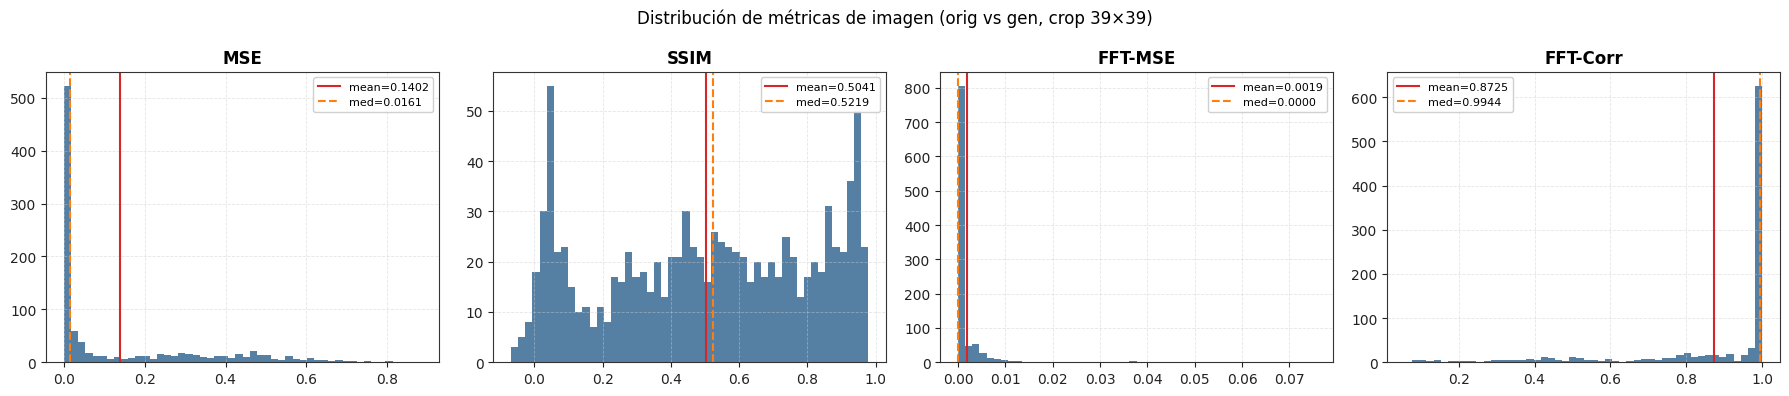

In [ ]:
summary_img = pd.DataFrame({
    "Estadístico": ["mean","median","p95","std"],
    "MSE":      [df_img["mse"].mean(),   df_img["mse"].median(),
                  df_img["mse"].quantile(.95), df_img["mse"].std()],
    "SSIM":     [df_img["ssim"].mean(),  df_img["ssim"].median(),
                  df_img["ssim"].quantile(.95), df_img["ssim"].std()],
    "FFT-MSE":  [df_img["fft_mse"].mean(), df_img["fft_mse"].median(),
                  df_img["fft_mse"].quantile(.95), df_img["fft_mse"].std()],
    "FFT-Corr": [df_img["fft_corr"].mean(), df_img["fft_corr"].median(),
                  df_img["fft_corr"].quantile(.95), df_img["fft_corr"].std()],
})
display_df(summary_img,
    title=f"Métricas de imagen — crop [:39,:39] aplicado (n={N_pts})",
    num_cols=["MSE","SSIM","FFT-MSE","FFT-Corr"], nd=5)

# Distribuciones
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col, title in zip(axes,
    ["mse","ssim","fft_mse","fft_corr"],
    ["MSE","SSIM","FFT-MSE","FFT-Corr"]):
    ax.hist(df_img[col], bins=50, color=COLOR_ORIG, alpha=0.8, edgecolor="none")
    ax.axvline(df_img[col].mean(), color="#d62728", lw=1.5, label=f"mean={df_img[col].mean():.4f}")
    ax.axvline(df_img[col].median(), color="#ff7f0e", lw=1.5, ls="--", label=f"med={df_img[col].median():.4f}")
    ax.set_title(title); ax.legend(fontsize=8)
fig.suptitle("Distribución de métricas de imagen (orig vs gen, crop 39×39)")
plt.tight_layout()
plt.savefig("ciclo_imagen_metrics.png")
plt.show()

## 12 · Galería de generación — muestras aleatorias (`cmap=jet`)

Cada fila: imagen original del dataset | imagen generada por DDPM | diferencia absoluta.
Las imágenes se muestran tras crop `[:39,:39]` con la máscara del disco.

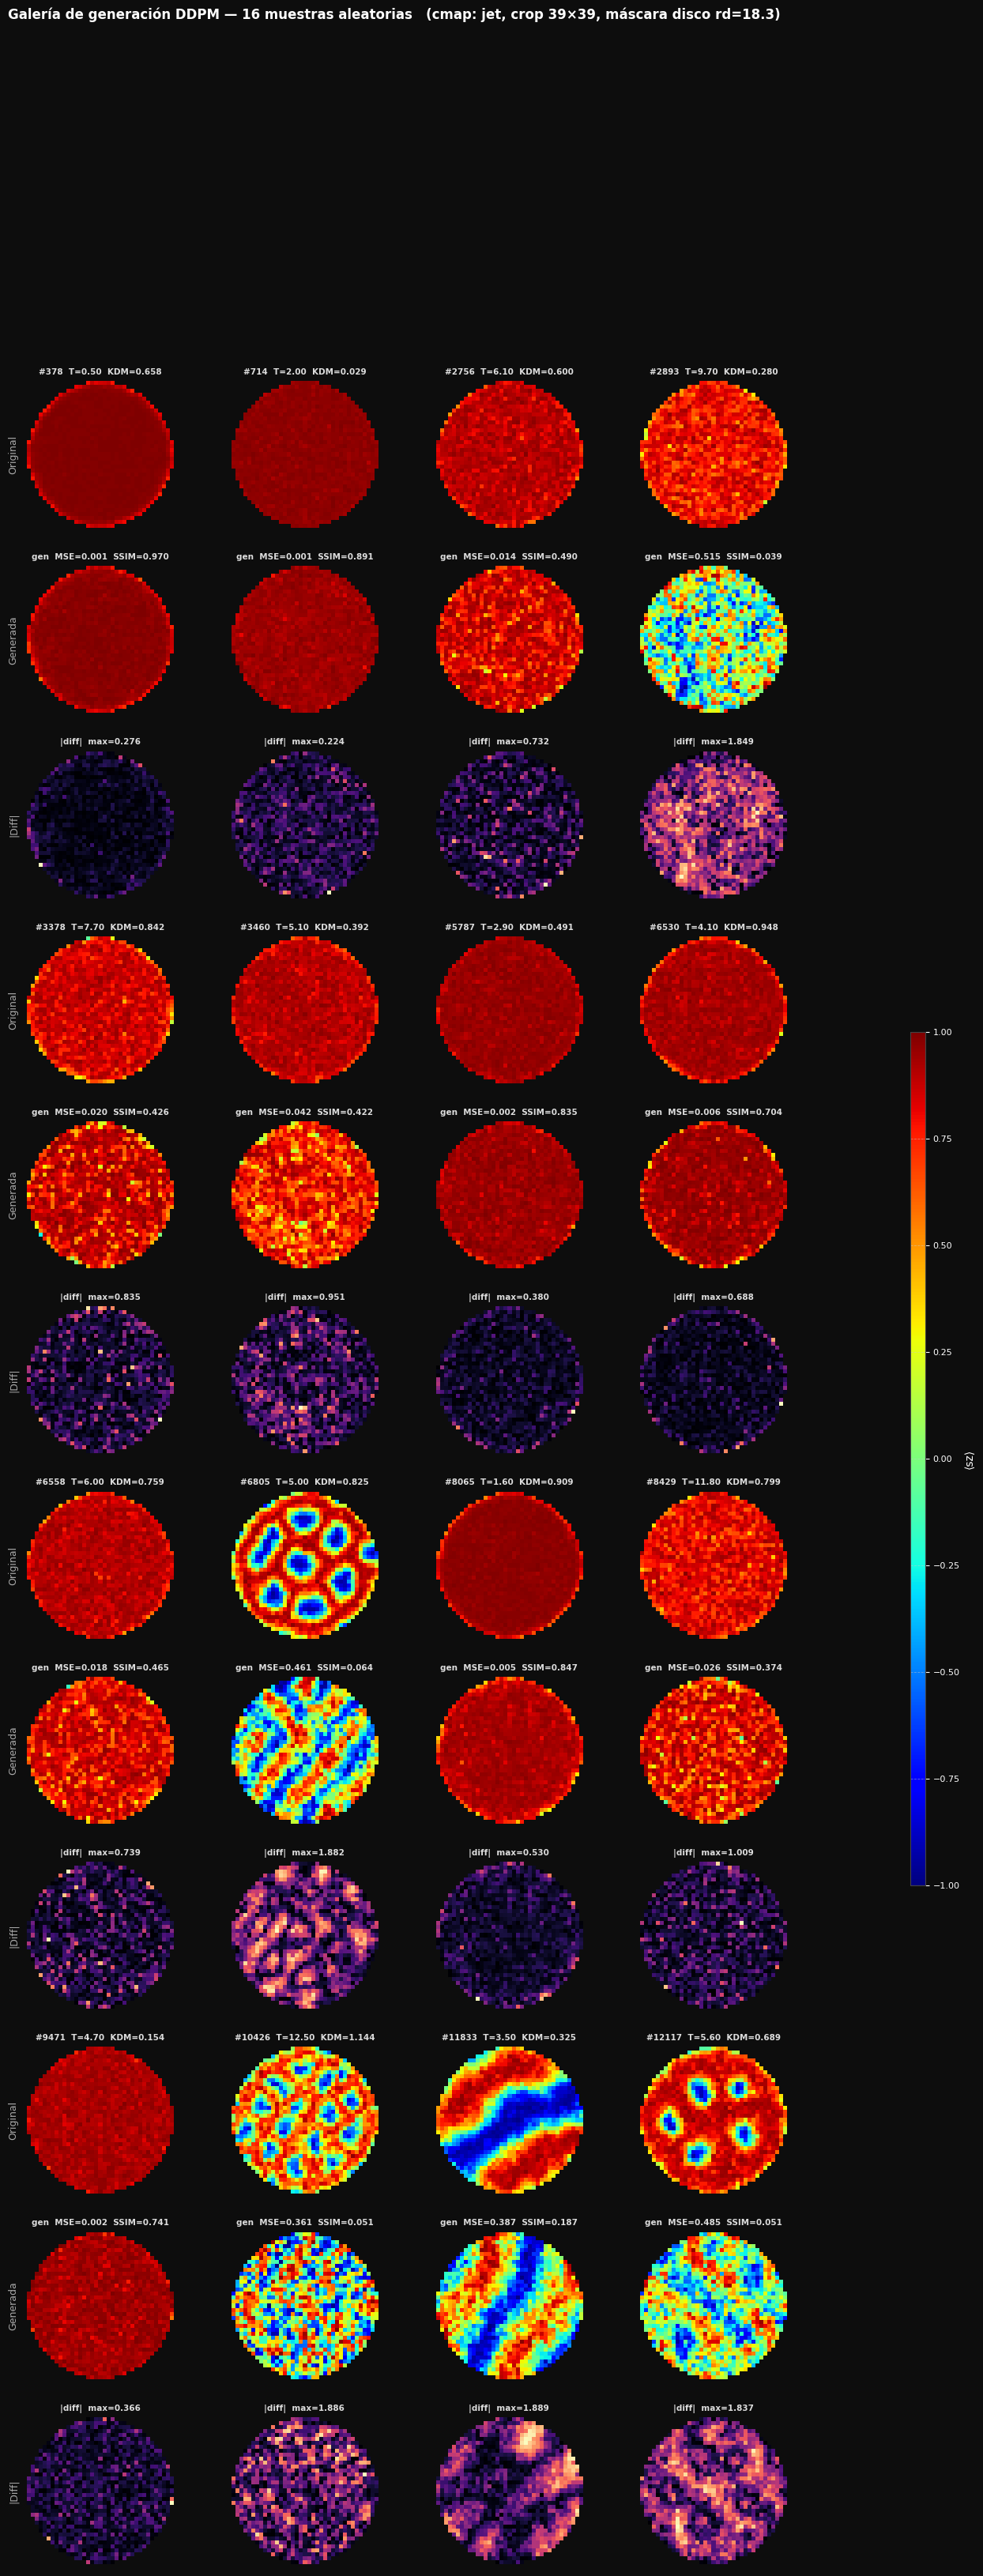

✓ Galería guardada: ciclo_galeria_generacion.png


In [ ]:
# ── Config galería ────────────────────────────────────────────────────────────
N_GALLERY = 16    # número de muestras a mostrar
SEED_GAL  = 0
BG        = "#0d0d0d"
N_COLS    = 4     # columnas (cada columna = 1 muestra: orig | gen | diff)
# ─────────────────────────────────────────────────────────────────────────────

cmap_jet = plt.colormaps["jet"].copy()
cmap_jet.set_bad(color=BG)

rng_gal = np.random.RandomState(SEED_GAL)
sel     = np.sort(rng_gal.choice(N_pts, size=min(N_GALLERY, N_pts), replace=False))

N_ROWS = math.ceil(len(sel) / N_COLS)

# Cada muestra ocupa 3 subplots: orig | gen | diff
fig, axes = plt.subplots(N_ROWS * 3, N_COLS,
                          figsize=(N_COLS * 3.2, N_ROWS * 9.0),
                          facecolor=BG)
axes = np.array(axes).reshape(N_ROWS, 3, N_COLS)

for idx_in_sel, k in enumerate(sel):
    row = idx_in_sel // N_COLS
    col = idx_in_sel % N_COLS

    # Crop a 39×39 y aplicar máscara (NaN fuera del disco)
    orig = crop39(imgs_orig_40[k]).astype(np.float64)
    gen  = crop39(imgs_gen_40[k]).astype(np.float64)
    orig_m = orig.copy(); orig_m[~DISK_MASK] = np.nan
    gen_m  = gen.copy();  gen_m[~DISK_MASK]  = np.nan
    diff   = np.abs(orig - gen)
    diff_m = diff.copy(); diff_m[~DISK_MASK] = np.nan

    T_val   = float(y_in[k, PARAM_NAMES.index("T")])
    KDM_val = float(y_in[k, PARAM_NAMES.index("KDM")])
    mse_k   = metric_mse(crop39(imgs_orig_40[k]), crop39(imgs_gen_40[k]))
    ssim_k  = metric_ssim(crop39(imgs_orig_40[k]), crop39(imgs_gen_40[k]))

    for ax_row in axes[row, :, col]:
        ax_row.set_facecolor(BG)
        ax_row.set_xticks([]); ax_row.set_yticks([])
        ax_row.set_frame_on(False)

    # Original
    ax_o = axes[row, 0, col]
    im_o = ax_o.imshow(orig_m, cmap=cmap_jet, vmin=-1, vmax=1,
                        interpolation="nearest", origin="lower")
    ax_o.set_title(f"#{eval_idx[k]}  T={T_val:.2f}  KDM={KDM_val:.3f}",
                   color="#ddd", fontsize=7.5, pad=3)

    # Generada
    ax_g = axes[row, 1, col]
    im_g = ax_g.imshow(gen_m, cmap=cmap_jet, vmin=-1, vmax=1,
                        interpolation="nearest", origin="lower")
    ax_g.set_title(f"gen  MSE={mse_k:.3f}  SSIM={ssim_k:.3f}",
                   color="#ddd", fontsize=7.5, pad=3)

    # Diferencia
    ax_d = axes[row, 2, col]
    vmax_d = max(float(np.nanmax(diff_m)), 1e-6)
    cmap_diff = plt.colormaps["magma"].copy(); cmap_diff.set_bad(color=BG)
    im_d = ax_d.imshow(diff_m, cmap=cmap_diff, vmin=0, vmax=vmax_d,
                        interpolation="nearest", origin="lower")
    ax_d.set_title(f"|diff|  max={vmax_d:.3f}",
                   color="#ddd", fontsize=7.5, pad=3)

# Colorbar jet compartida
from matplotlib.colors import Normalize
cbar_ax = fig.add_axes([1.01, 0.35, 0.015, 0.3])
cb = fig.colorbar(plt.cm.ScalarMappable(norm=Normalize(-1,1), cmap="jet"), cax=cbar_ax)
cb.set_label("⟨sz⟩", color="white", fontsize=10)
cb.ax.yaxis.set_tick_params(color="white")
plt.setp(cb.ax.yaxis.get_ticklabels(), color="white", fontsize=8)
cb.outline.set_edgecolor("#444")

# Etiquetas de filas
for r in range(N_ROWS):
    axes[r, 0, 0].set_ylabel("Original",  color="#aaa", fontsize=9)
    axes[r, 1, 0].set_ylabel("Generada",  color="#aaa", fontsize=9)
    axes[r, 2, 0].set_ylabel("|Diff|",    color="#aaa", fontsize=9)

fig.suptitle(f"Galería de generación DDPM — {len(sel)} muestras aleatorias   "
             f"(cmap: jet, crop 39×39, máscara disco rd={RD_PIXELS})",
             color="white", fontsize=12, fontweight="bold", y=1.01)

plt.savefig("ciclo_galeria_generacion.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()
print(f"✓ Galería guardada: ciclo_galeria_generacion.png")

## 13 · Exportar resultados

In [ ]:
df_reg.to_csv("ciclo_params_r2_mae.csv", index=False)
summary_img.to_csv("ciclo_imagen_metrics.csv", index=False)

display_df(df_reg, title="ciclo_params_r2_mae.csv",
    num_cols=["MAE","RMSE","R²","range","nMAE_%"], nd=4)

print("Archivos exportados:")
print("  ciclo_params_r2_mae.csv")
print("  ciclo_imagen_metrics.csv")
print("  ciclo_true_vs_pred.png")
print("  ciclo_imagen_metrics.png")
print("  ciclo_galeria_generacion.png")

param,MAE,RMSE,R²,range,nMAE_%
T,0.8669,1.2964,0.8750,19.8000,4.3783
Jex2,0.0685,0.1224,0.0000,0.0000,—
Jex3,0.0263,0.0465,0.0000,0.0000,—
Jex4,0.0204,0.0352,0.0000,0.0000,—
Kan1,0.0780,0.0974,-1.7384,0.1980,39.3840
KanS,0.0878,0.1043,-2.2518,0.2000,43.8910
Hex,0.5422,0.6784,-1.4886,1.4930,36.3187
KDM,0.2210,0.3149,0.1966,1.1970,18.4657


Archivos exportados:
  ciclo_params_r2_mae.csv
  ciclo_imagen_metrics.csv
  ciclo_true_vs_pred.png
  ciclo_imagen_metrics.png
  ciclo_galeria_generacion.png
